# Uncalibrated risk calculations

This notebook will walk through the a risk calculation in CLIMADA with the uncalibrated data.

It will read in data, create the CLIMADA objects needed for the analysis, run the risk calculation, and explore the outputs including plots and statistics.

This analysis is being performed with the _uncalibrated_ Entity files containing our first guess impact functions. Therefore the purpose of this notebook is also to notice the shortcomings of the analysis and identify how it has to be improved.

In [1]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILES = ["ICA_PERU_Entity_Floods_Residential.xlsx", "ICA_PERU_Entity_Floods_People.xlsx", "ICA_PERU_Entity_Floods_Road.xlsx"]
entity_filepaths = [Path(ENTITY_DIR) / filename for filename in ENTITY_FILES]

HAZARD_DIR = "../data/hazard/"
HAZARD_FILES = ["tr10_h_max_61200_4326.tif", "tr25_h_max_61200_4326.tif", "tr50_h_max_61200_4326.tif", "tr100_h_max_61200_4326.tif", "tr200_h_max_61200_4326.tif", "tr500_h_max_72000_4326.tif"]
haz_filepaths = [Path(HAZARD_DIR) / filename for filename in HAZARD_FILES]

## Read in data

### Entity files

In [2]:
import copy
from climada.entity import Entity

RESIDENCE_VALUE_USD = 97398     # Value of a home chosen from the literature
RESIDENCE_RECOVERY_USD = 4300   # Cost to repair and refit a damaged home, from government statistics
RESIDENCE_REBUILD_USD = 6300    # Cost to rebuild a destroyed home, from government statistics

ROAD_KM_VALUE_USD = 1000000     # Cost to rebuild a km of damaged road, from government statistics


# Read the Entity file and set additional metadata for the Exposures
entity_list = []
for entity_path in entity_filepaths:
    print(f"Reading {entity_path.name}...")
    entity = Entity.from_excel(entity_path)
    entity.exposures.ref_year = 2026
    entity.exposures.value_unit = "People" if "People" in entity_path.name else "USD"   # This needs to be specified but will be read from the Excel file after the next release
    entity.exposures.description = f"Exposures from {entity_path.name}"
    entity_list.append(entity)

entity_residences, entity_people, entity_roads = entity_list
entity_names = ["residences (economic impact)", "people (affected)", "roads (economic impact)"]

Reading ICA_PERU_Entity_Floods_Residential.xlsx...
Reading ICA_PERU_Entity_Floods_People.xlsx...
Reading ICA_PERU_Entity_Floods_Road.xlsx...


### Plot exposures

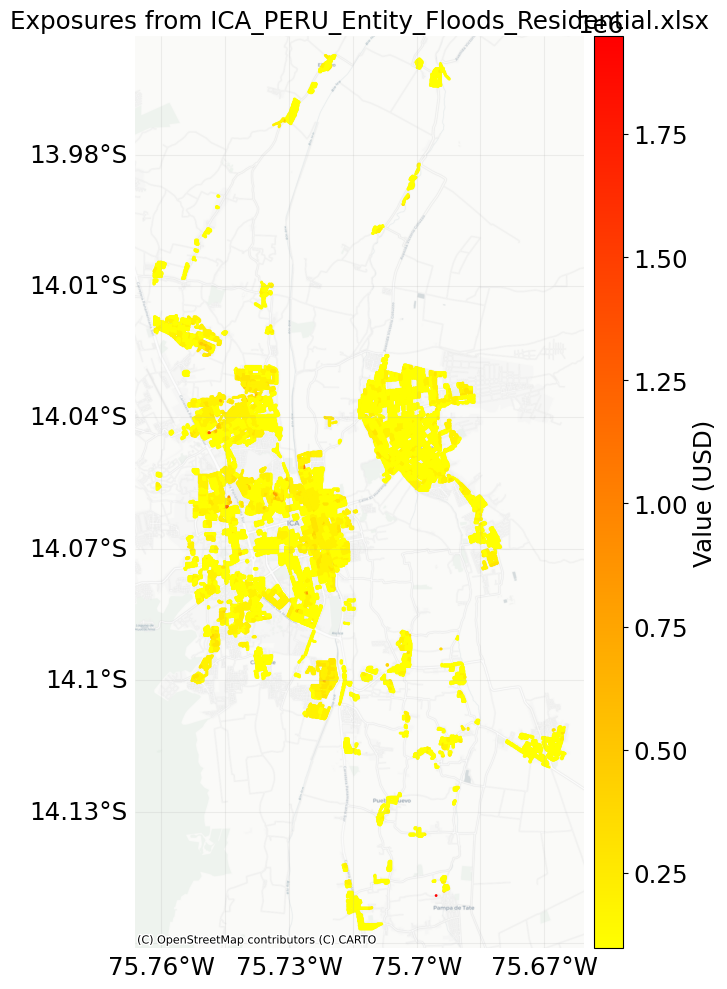

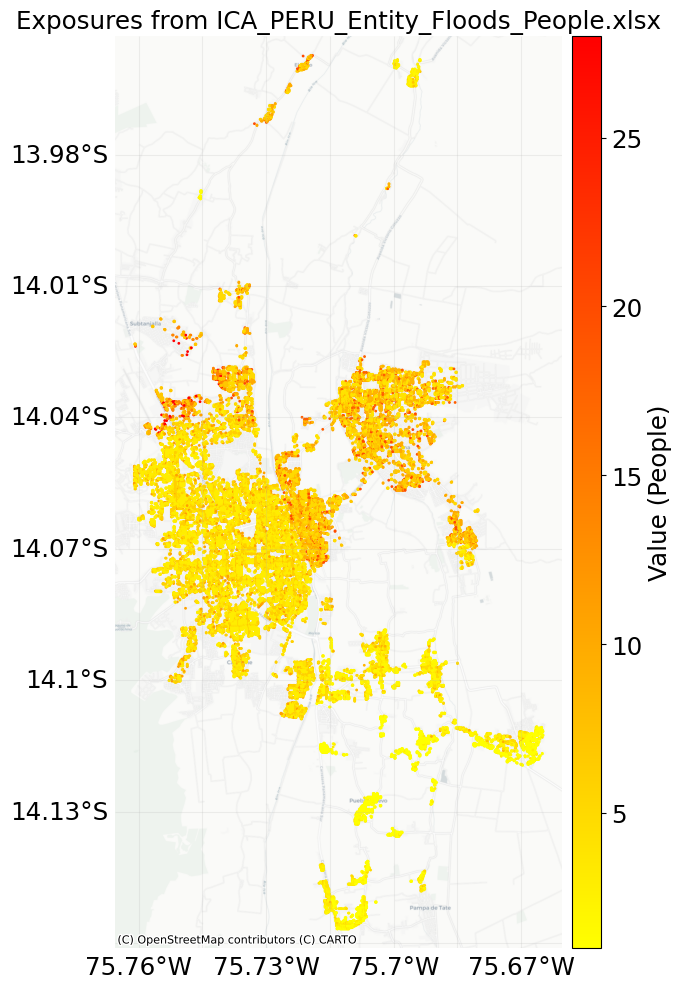

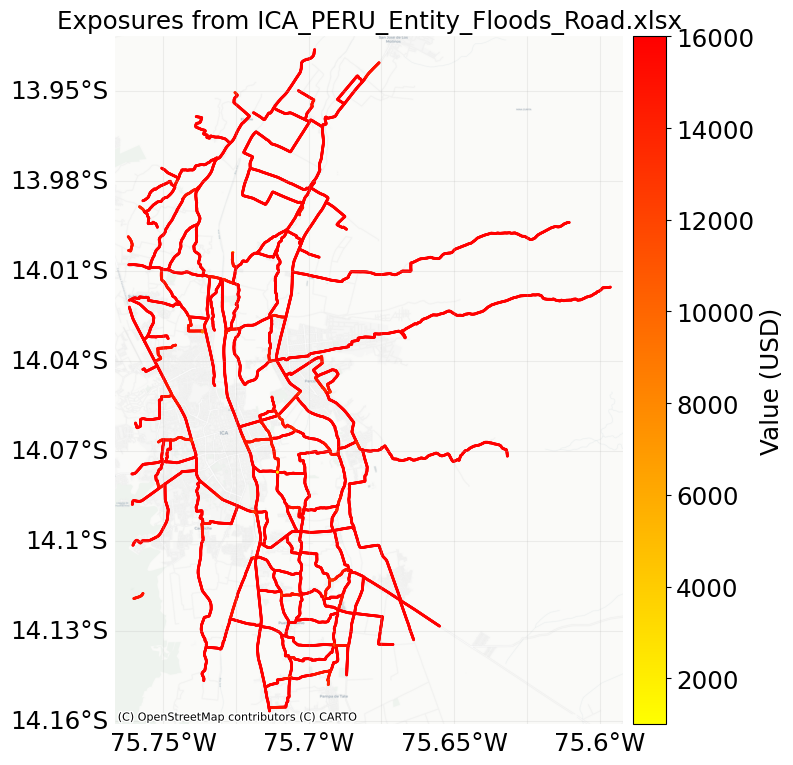

In [3]:
%matplotlib inline

for entity in entity_list:
    entity.exposures.plot_basemap(
        title=entity.exposures.description,
        ignore_zero=True,       # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=14,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)         # Dimensions of the output figure
    )

### Plot impact functions

- The Residential Entity file contains three first-guess impact functions: a generalized damage curve for economic impacts, and two step functions that count affected and destroyed housing.
- The People Entity file contains two first-guess impact functions: step functions that count people affected and 'victims' – roughly corresponding to people who were displaced from their homes.
- The Roads Entity file contains a single first-guess impact function.

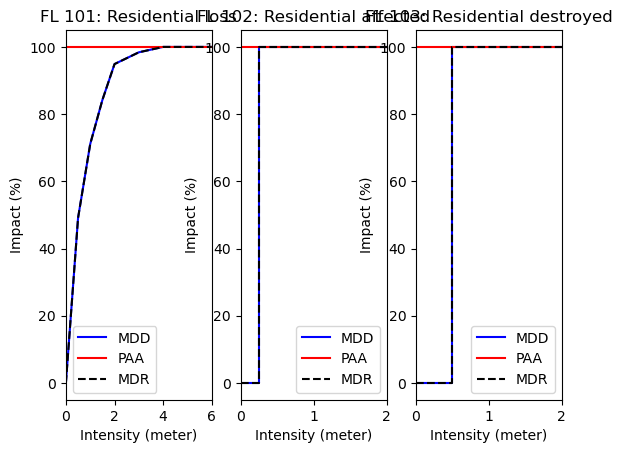

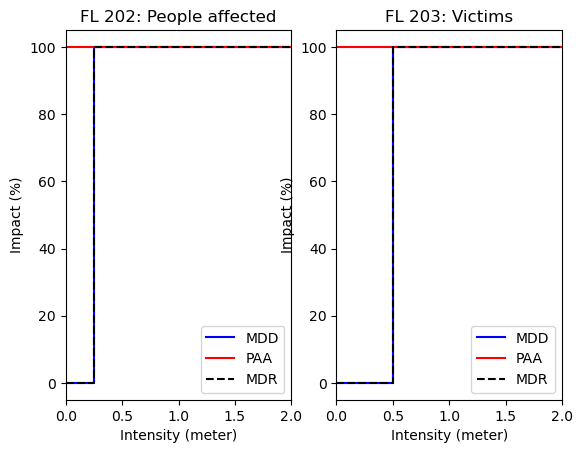

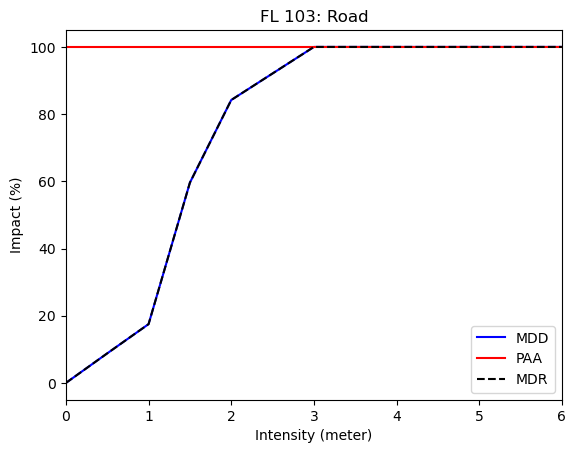

In [4]:
for entity in entity_list:
    entity.impact_funcs.plot()

### Hazard

In [5]:
import copy
import numpy as np
from climada.hazard import Hazard

# Read the hazard data

# Since we're reading hazard data from .tif files, we need to provide some additional metadata, including a frequency for each event
# As shown in the Hazard notebook, we have to convert return period frequencies to event frequencies:
HAZARD_RETURN_PERIODS = [10, 25, 50, 100, 200, 500]

def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]  # Reverse the list so that it's in order of increasing frequency (decreasing return period)
    exceedance_frequency = np.array([1/rp for rp in rp_rev])
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency]))
    event_frequency = event_frequency[::-1]  # Reverse the frequencies so that they match the order of the events in the hazard file again
    return event_frequency

event_frequency = event_frequency_from_return_periods(HAZARD_RETURN_PERIODS)


# Read in the hazard data
haz = Hazard.from_raster(
    files_intensity = haz_filepaths,
    attrs={
        'unit': 'm',
        'event_name': [f'Return period {rp}' for rp in HAZARD_RETURN_PERIODS],     # We can optionally name the events
        'frequency': event_frequency                                         # For probabilistic analyses we have to define the frequency of each event
    },
    haz_type='FL',
    window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
    geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
)

2026-07-07 17:17:40,763 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-07-07 17:17:49,273 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-07-07 17:17:49,460 - climada.util.coordinates - INFO - Reading ../data/hazard/tr25_h_max_61200_4326.tif
2026-07-07 17:17:49,674 - climada.util.coordinates - INFO - Reading ../data/hazard/tr50_h_max_61200_4326.tif
2026-07-07 17:17:50,020 - climada.util.coordinates - INFO - Reading ../data/hazard/tr100_h_max_61200_4326.tif
2026-07-07 17:17:50,245 - climada.util.coordinates - INFO - Reading ../data/hazard/tr200_h_max_61200_4326.tif
2026-07-07 17:17:50,430 - climada.util.coordinates - INFO - Reading ../data/hazard/tr500_h_max_72000_4326.tif


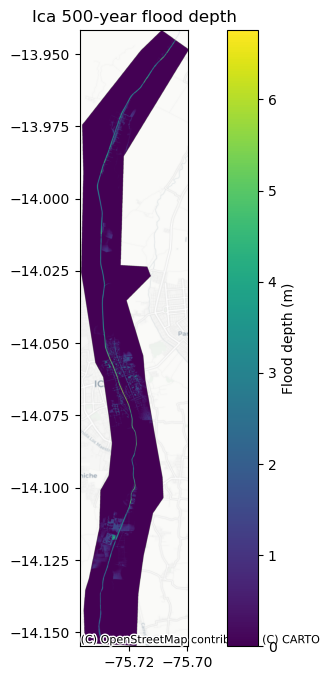

In [6]:
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx

# Plot most intense values from all events
# (This can be _very_ slow: the hazard is a very large dataset, and CLIMADA is slow to visualize it)
# _ = haz.plot_intensity(event=0)

# Instead: plot the highest return period raster file using rasterio and matplotlib directly
raster_path = haz_filepaths[-1]

with rasterio.open(raster_path) as src:
    raster_data = src.read(1, masked=True)

    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    raster_crs = src.crs

fig, ax = plt.subplots(figsize=(10, 8))

# Set map extent to raster bounds (in raster CRS, EPSG:4326 here)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Add basemap
ctx.add_basemap(ax, crs=raster_crs, source=ctx.providers.CartoDB.Positron, zoom=13)

# Overlay raster
img = ax.imshow(
    raster_data,
    extent=extent,
    cmap="viridis",
    origin="upper",
)

plt.colorbar(img, ax=ax, label="Flood depth (m)")
ax.set_title(f"Ica 500-year flood depth")
plt.show()


In [7]:
# Drop hazard centroids with zero hazard

# Unusually for a CLIMADA simulation, we want to remove locations with zero modelled hazard. This is because the flood simulation's very detailed DEM recognises the roofs of houses and doesn't model hazard at these locations.
# We solve this by removing centroids located within the housing polygons – and anywhere else that never experiences a hazard – we want rooftops to be _missing_ values rather than _zero_ values, forcing CLIMADA to use flood information from non-missing locations, i.e. the nearby streets.

intensity_threshold = 0.05       # [5 cm and less we'll ignore. Maybe this should be 0. Maybe this should be more – you can experiment]
ix = haz.intensity.max(axis=0) < intensity_threshold    # Use the hazard intensity matrix to identify centroids 
assert ix.sum() > 0     # Ensure this hasn't removed all cpoints
ix = ix.todense().A1  # Convert from sparse matrix to 1D array of booleans
# Remove any grid cells with zero intensity across all events
haz.centroids.gdf["region_id"] = ix.astype(int)   # (bit hacky) set the hazard's centroid region IDs to 0 (centroid affected) or 1 (centroid never affected)
haz = haz.select(reg_id=0)  # Subset the Hazard to only include grid cells with non-zero intensity across all events

/usr/local/Caskroom/miniforge/base/envs/climada_env/lib/python3.11/site-packages/scipy/sparse/_base.py:463: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  return self.tocsr().__lt__(other)


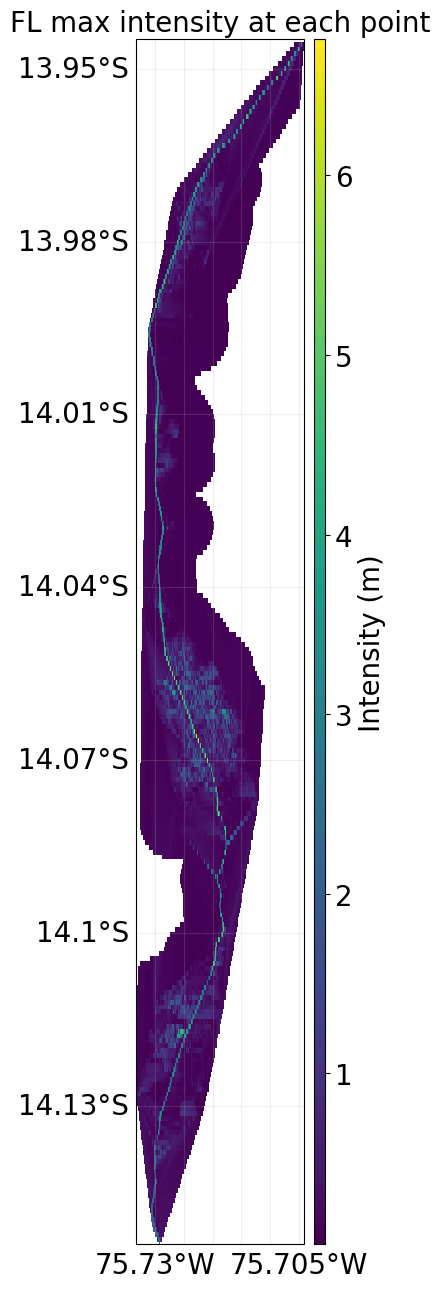

In [8]:
# Plot most intense values from all events
# (this is faster now that we've removed zero-hazard centroids)
_ = haz.plot_intensity(event=0)

## Map Hazard centroids to Exposure points

When CLIMADA is given a hazard and an exposure dataset it has to infer the value of the hazard at every exposure point. Often the hazard centroids and the exposure locations do not line up exactly. In these cases, CLIMADA finds the closest hazard centroid for each exposure, within a certain maximum search distance, set by a `threshold` parameter (or estimated by the model if not provided).

Usually CLIMADA's automated estimate can do this matching well. But sometimes you want to set this manually, most commonly when
- The hazard data is not defined on a regular grid, or
- The hazard data has a lot of missing values (rather than 0 values), or
- The hazard is very detailed – as here

The hazard in this dataset is so detailed that many buildings with a flooded street outside are not close enough to a flooded pixel for CLIMADA's automated centroid assignment to register the buiolding as affected. So we need to specify the search distance manually.

Here we can visualise that process.

Search distances that are too high will result in flooded properties that are unreastically far from any hazard. Search distances that are too low will result in not enough properties being registered as flooded.

In the plots created below, exposed points are plotted alongside hazard centroids and shaded according to whether they have been mapped to a nearby hazard centroid, with a different matching threshold in each plot. Points in blue have been matched to a nearby centroid whereas points in red are considered to be unaffected.


2026-07-07 17:18:47,125 - climada.entity.exposures.base - INFO - Matching 209 exposures with 2094 centroids.
2026-07-07 17:18:47,140 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 7.237582121888408e-05 degree
2026-07-07 17:18:47,150 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000072 degree for 105 coordinates.
2026-07-07 17:18:48,221 - climada.entity.exposures.base - INFO - Matching 209 exposures with 2094 centroids.
2026-07-07 17:18:48,228 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0001 degree
2026-07-07 17:18:48,233 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000100 degree for 70 coordinates.
2026-07-07 17:18:49,032 - climada.entity.exposures.base - INFO - Matching 209 exposures with 2094 centroids.
2026-07-07 17

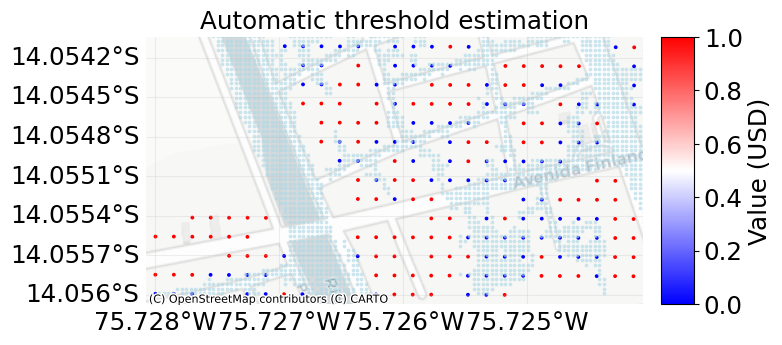

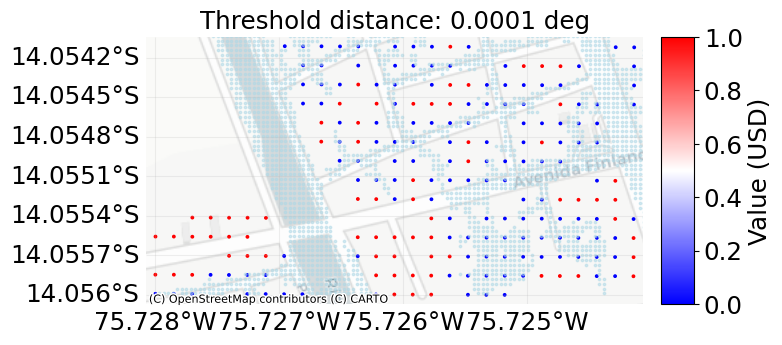

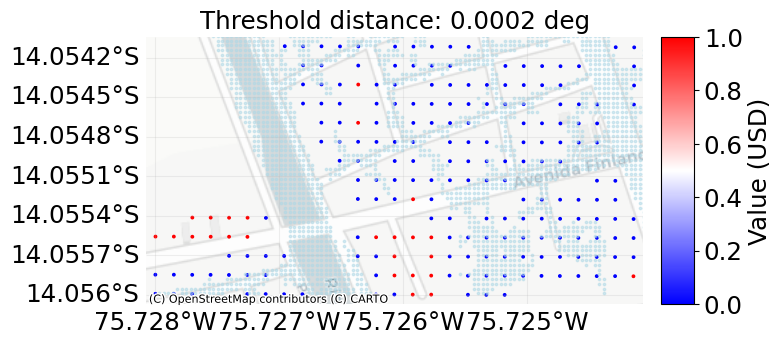

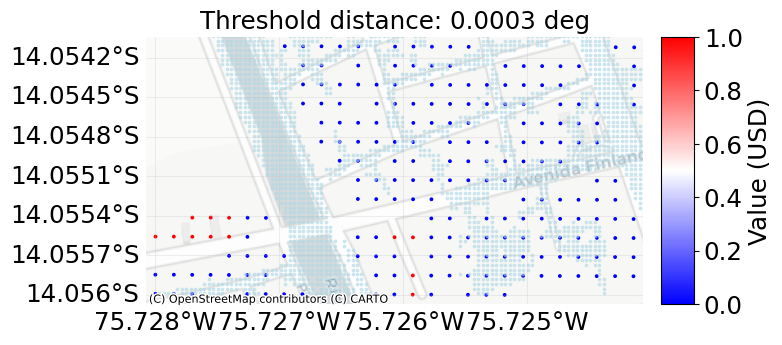

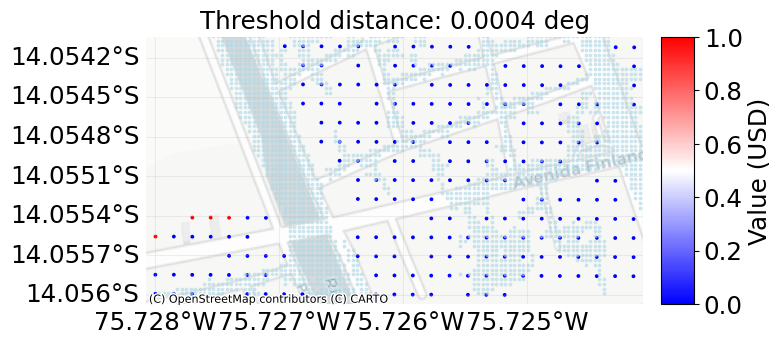

In [9]:
import pandas as pd
import cartopy.crs as ccrs
from matplotlib import pyplot as plt

# Test different distance thresholds for matching exposures to hazard centroids
# 'None' will test CLIMADA's default threshold estimation.
distance_thresholds_to_test = [None, 0.0001, 0.0002, 0.0003, 0.0004]
# Zoom in to a very small area for the visualization
extent_streetlevel = (-75.728, -75.724, -14.056, -14.054)  # (min_lon, max_lon, min_lat, max_lat)

# Copy and subset the hazard to this small area
haz_streetlevel = copy.deepcopy(haz)
haz_streetlevel = haz_streetlevel.select(extent=extent_streetlevel)

# Take the housing Entity for this example, and subset to the same small area 
def subset_exposures_to_extent(exposures, extent):
    lon_min, lon_max, lat_min, lat_max = extent
    exposures_streetlevel = copy.deepcopy(exposures)
    new_gdf = copy.deepcopy(exposures_streetlevel.gdf)
    sel_ix = (
                (exposures_streetlevel.longitude >= lon_min)
                & (exposures_streetlevel.longitude <= lon_max)
                & (exposures_streetlevel.latitude >= lat_min)
                & (exposures_streetlevel.latitude <= lat_max)
            )
    new_gdf = new_gdf[sel_ix]
    exposures_streetlevel.set_gdf(new_gdf)
    return exposures_streetlevel

residences_zoom = subset_exposures_to_extent(entity_residences.exposures, extent_streetlevel)

# A method to assign hazard centroids to the exposures according to a distance threshold and plot the results
def plot_exposures_within_threshold(haz, exp, dist_threshold, figsize=(8, 10)):
    exp_thresh = copy.deepcopy(exp)
    # Match exposures to hazard centroids within the threshold distance
    if dist_threshold is not None:
        exp_thresh.assign_centroids(hazard=haz, threshold=dist_threshold, overwrite=True)
    else:
        exp_thresh.assign_centroids(hazard=haz, overwrite=True)

    # Label the matched points in the Exposures geodataframe
    new_gdf = exp_thresh.gdf.copy()
    new_gdf["value"] = exp_thresh.hazard_centroids(haz_type="FL") == -1
    exp_thresh.set_gdf(new_gdf)
    # Plot the matched points
    title = f"Threshold distance: {dist_threshold} deg" if dist_threshold is not None else "Automatic threshold estimation"
    axis = exp_thresh.plot_basemap(
        title=title,
        ignore_zero=False,       # Whether to plot points with zero value
        buffer=8,                # Add a buffer around the points to show a larger map region (measured in meters)
        s=3,                     # The size of point markers on the plot
        zoom=17,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=1,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="bwr",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=figsize,        # Dimensions of the output figure
    )
    haz.centroids.gdf.plot(ax=axis, transform=ccrs.PlateCarree(), color="lightblue", alpha=0.5, markersize=3, label="Hazard centroids")
    return axis

for dist_threshold in distance_thresholds_to_test:
    _ = plot_exposures_within_threshold(haz_streetlevel, residences_zoom, dist_threshold, figsize=(8, 10))

From this it looks like a good threshold is 0.0002 – at this matching distances we see that most of a housing block is affected by a nearby flooded street, but neighbouring streets without flooding are unaffected. (Further work could investigate the sensitivity of the calibration and results to this choice of threshold.)

We can repeat the analysis for Roads, which look a little different from housing and people:

2026-07-07 17:18:53,936 - climada.entity.exposures.base - INFO - Matching 17 exposures with 2094 centroids.
2026-07-07 17:18:53,943 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 7.237582121888408e-05 degree
2026-07-07 17:18:53,948 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000072 degree for 4 coordinates.
2026-07-07 17:18:54,592 - climada.entity.exposures.base - INFO - Matching 17 exposures with 2094 centroids.
2026-07-07 17:18:54,596 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0001 degree
2026-07-07 17:18:55,207 - climada.entity.exposures.base - INFO - Matching 17 exposures with 2094 centroids.
2026-07-07 17:18:55,212 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold 

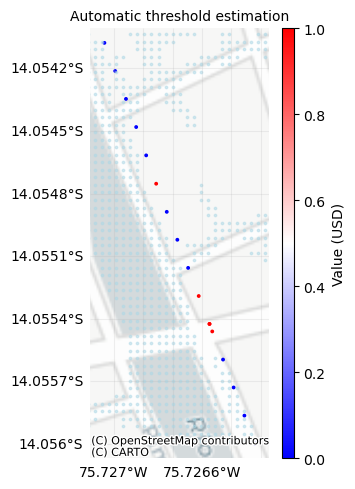

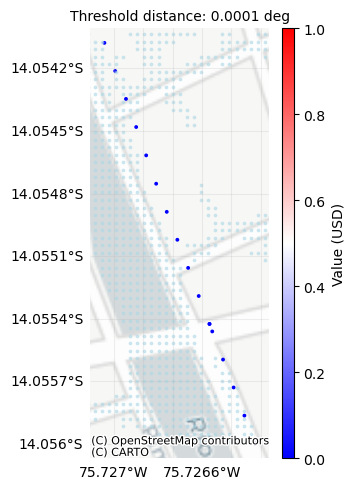

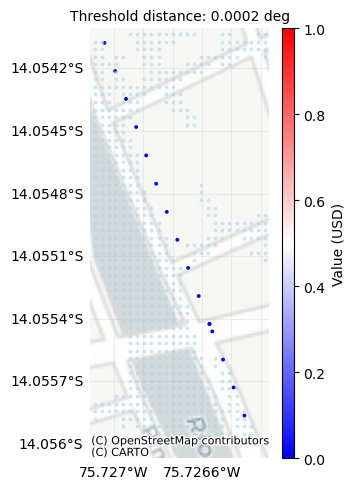

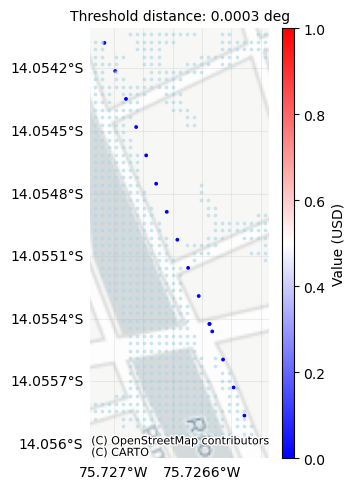

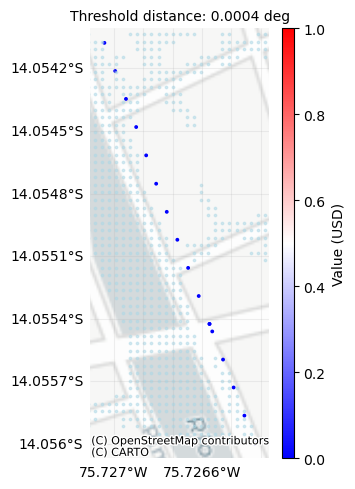

In [10]:
roads_zoom = subset_exposures_to_extent(entity_roads.exposures, extent_streetlevel)

for dist_threshold in distance_thresholds_to_test:
    _ = plot_exposures_within_threshold(haz_streetlevel, roads_zoom, dist_threshold, figsize=(4, 5))

In [11]:
dist_threshold = 0.0002

for entity in entity_list:
    entity.exposures.assign_centroids(hazard=haz, threshold=dist_threshold, overwrite=True)

2026-07-07 17:18:59,919 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-07-07 17:19:00,377 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-07-07 17:19:01,315 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.
2026-07-07 17:19:01,326 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-07-07 17:19:01,706 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-07-07 17:19:02,827 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.
2026-07-07 17:19:02,836 - climada.entity.exposures.base - INFO - Matching 18640 exposures with 282071 centroids.
2026-07-0

## Calculate risk

With all these ingredients we can run risk calculations using CLIMADA's `ImpactCalc` class.

In the code below we only run one impact function for one entity file, but please run the calculations for other Exposure types and impact functions. The code includes a method to assign a different impact function to the Exposures so that you can test out other impact functions.

In [12]:
def change_entity_exposure_impf(entity, new_impf_id):
    new_gdf = copy.deepcopy(entity.exposures.gdf)
    new_gdf["impf_id"] = new_impf_id
    entity.exposures.set_gdf(new_gdf)
    return entity

In [13]:
from climada.engine import ImpactCalc, ImpactFreqCurve

# The ImpactCalc class sets up the calculation
imp_calc_residences = ImpactCalc(
    exposures=entity_residences.exposures,
    impfset=entity_residences.impact_funcs,
    hazard=haz
)
# ...and its .impact method runs the calculation, creating an Impact object
imp_residences_economic = imp_calc_residences.impact(
    save_mat=True,          # Save the impact matrix (see below). This can be large, but we want it to explore some additional calculations 
    assign_centroids=False  # Don't (re)assign centroids
)

2026-07-07 17:19:04,035 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


In [14]:
# And we can repeat this impact calculation for people and road exposures:

imp_calc_people = ImpactCalc(
    exposures=entity_people.exposures,
    impfset=entity_people.impact_funcs,
    hazard=haz
)
imp_people_affected = imp_calc_people.impact(
    save_mat=True,          # Save the impact matrix (see below) 
    assign_centroids=False  # Don't (re)assign centroids
)

imp_calc_roads = ImpactCalc(
    exposures=entity_roads.exposures,
    impfset=entity_roads.impact_funcs,
    hazard=haz
)
imp_roads_economic = imp_calc_roads.impact(
    save_mat=True,          # Save the impact matrix (see below) 
    assign_centroids=False  # Don't (re)assign centroids
)

2026-07-07 17:19:04,134 - climada.engine.impact_calc - INFO - Calculating impact for 17015 assets (>0) and 6 events.
2026-07-07 17:19:04,187 - climada.engine.impact_calc - INFO - Calculating impact for 6475 assets (>0) and 6 events.


The Impact object has properties and methods that support you in creating risk statistics.

At the core of it is the impact matrix, which is a sparse matrix with dimensions (number of events) x (number of exposure points). It gives the calculated impact of each event at each point of exposure.

We can print some of these properties, and plot event losses:

Number of exposures: 107016
Number of events: 6
Size of impact matrix: (6, 107016)
Total impact per event:
['Return period 10: 3,189,703', 'Return period 25: 19,007,911', 'Return period 50: 74,273,929', 'Return period 100: 179,308,134', 'Return period 200: 301,627,299', 'Return period 500: 524,835,116']
Average annual impact (AAI, or AAL) per event:
4165372.51


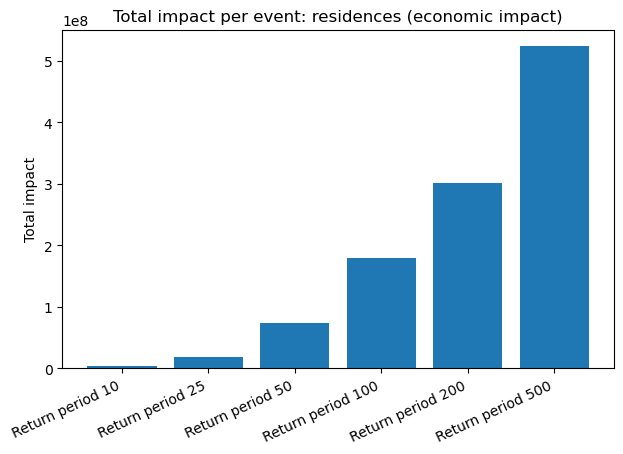

Number of exposures: 107016
Number of events: 6
Size of impact matrix: (6, 107016)
Total impact per event:
['Return period 10: 148', 'Return period 25: 509', 'Return period 50: 2,120', 'Return period 100: 6,067', 'Return period 200: 9,924', 'Return period 500: 17,188']
Average annual impact (AAI, or AAL) per event:
134.74


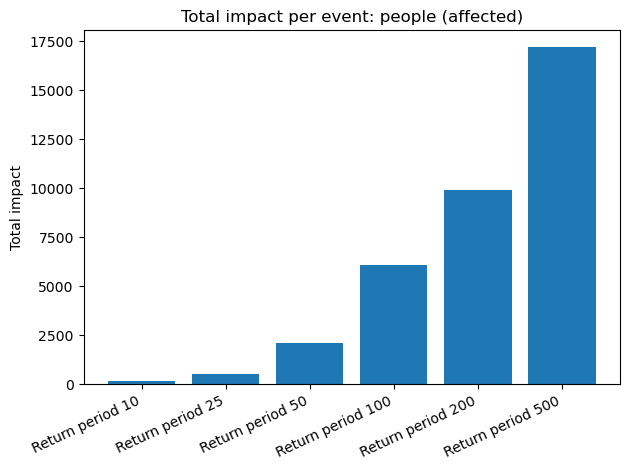

Number of exposures: 18640
Number of events: 6
Size of impact matrix: (6, 18640)
Total impact per event:
['Return period 10: 579,316', 'Return period 25: 1,062,769', 'Return period 50: 1,595,636', 'Return period 100: 2,165,116', 'Return period 200: 2,766,456', 'Return period 500: 3,859,235']
Average annual impact (AAI, or AAL) per event:
98814.14


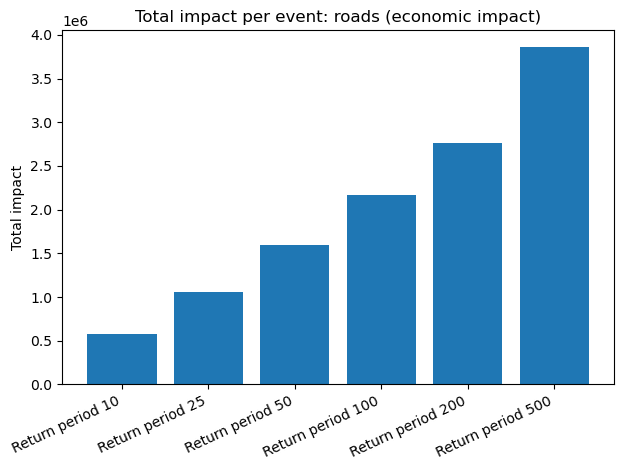

In [15]:
import matplotlib.pyplot as plt

for imp, asset_name in zip([imp_residences_economic, imp_people_affected, imp_roads_economic], entity_names):
    print(f"Number of exposures: {len(imp.eai_exp)}")
    print(f"Number of events: {len(imp.event_id)}")
    print(f"Size of impact matrix: {imp.imp_mat.shape}")

    # Summing the impact across all exposed points gives us the total impact per event. This is calculated during the impact calculation and stored in the `.at_event` attribute.
    print("Total impact per event:")
    print([f'{event_name}: {impact:,.0f}' for event_name, impact in zip(imp.event_name, imp.at_event)])

    # Combining the event-wise impacts with the events' frequencies let us calculate the average annual loss (AAL). This is stored in the `.aal_agg` attribute.
    print("Average annual impact (AAI, or AAL) per event:")
    print(f"{imp.aai_agg:.2f}")

    # Plot this array as a bar chart
    plt.bar(imp.event_name, imp.at_event)
    plt.ylabel("Total impact")
    plt.title(f"Total impact per event: {asset_name}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()



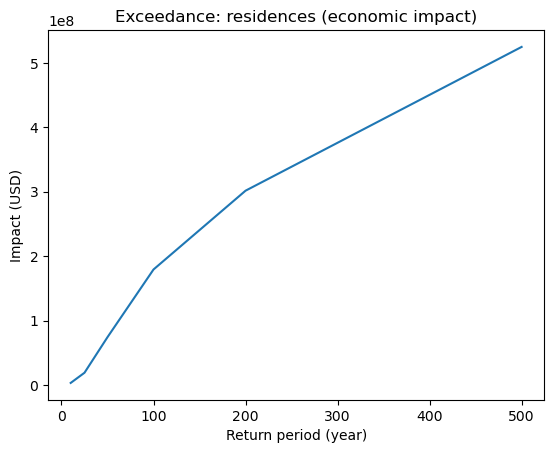

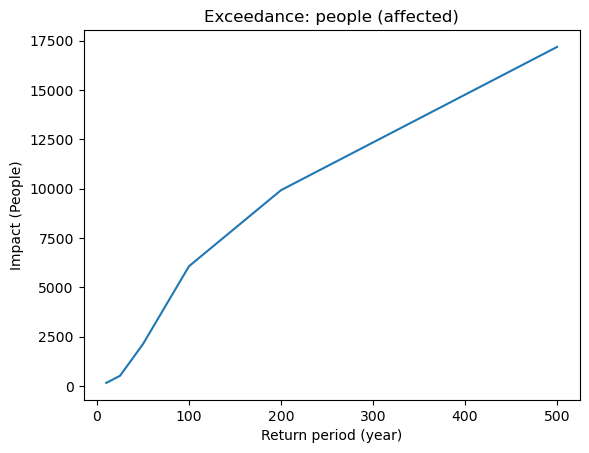

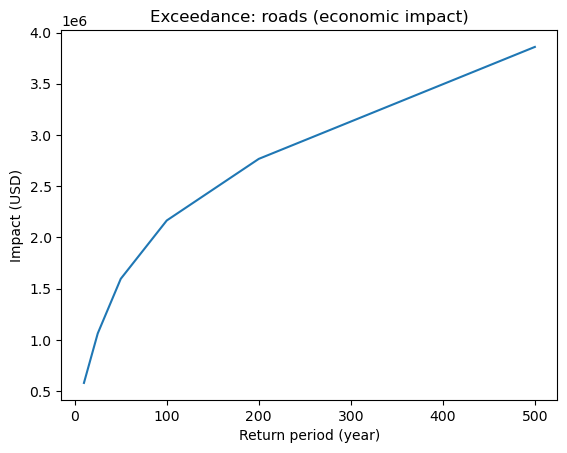

In [16]:
# We can extract an exceedance curve, showing how total losses change with return periods
# This method returns a ImpactFreqCurve object, which can be plotted.

for imp, asset_name in zip([imp_residences_economic, imp_people_affected, imp_roads_economic], entity_names):
    exceedance_curve = imp.calc_freq_curve(return_per=HAZARD_RETURN_PERIODS)
    axis = exceedance_curve.plot()
    axis.set_title(f"Exceedance: {asset_name}")


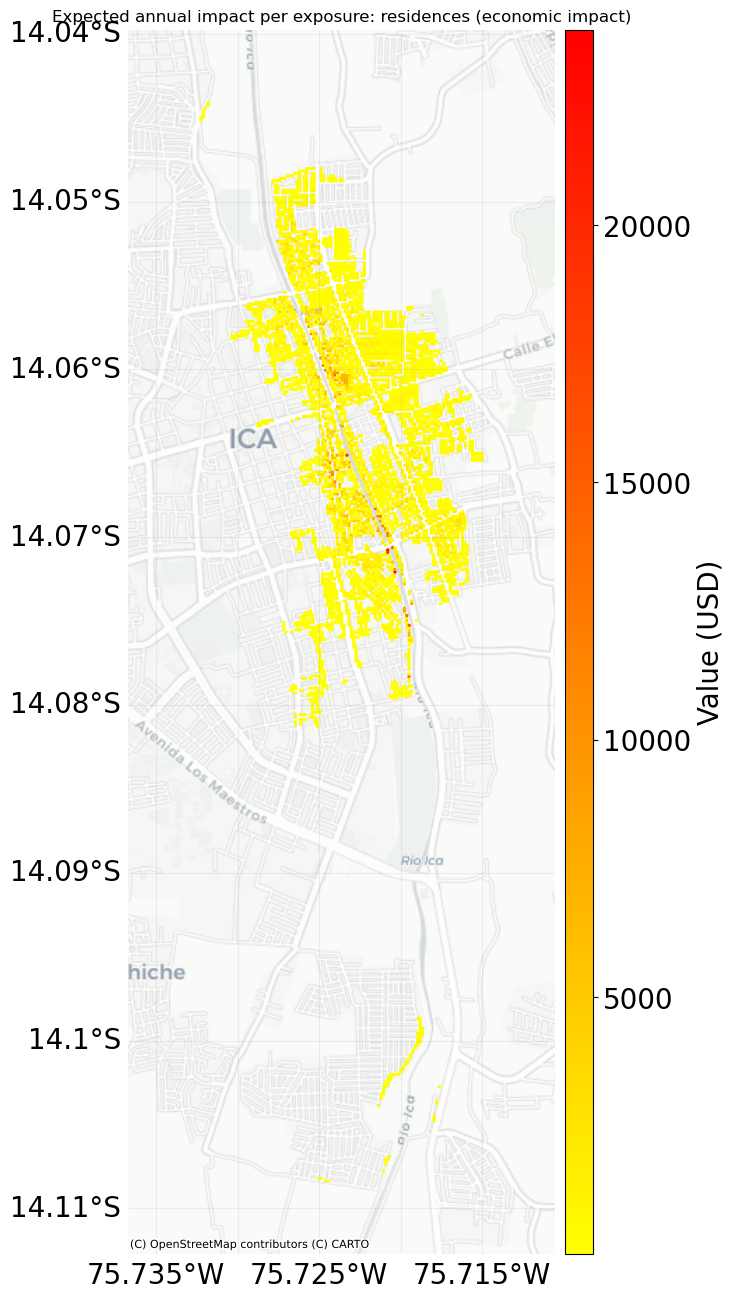

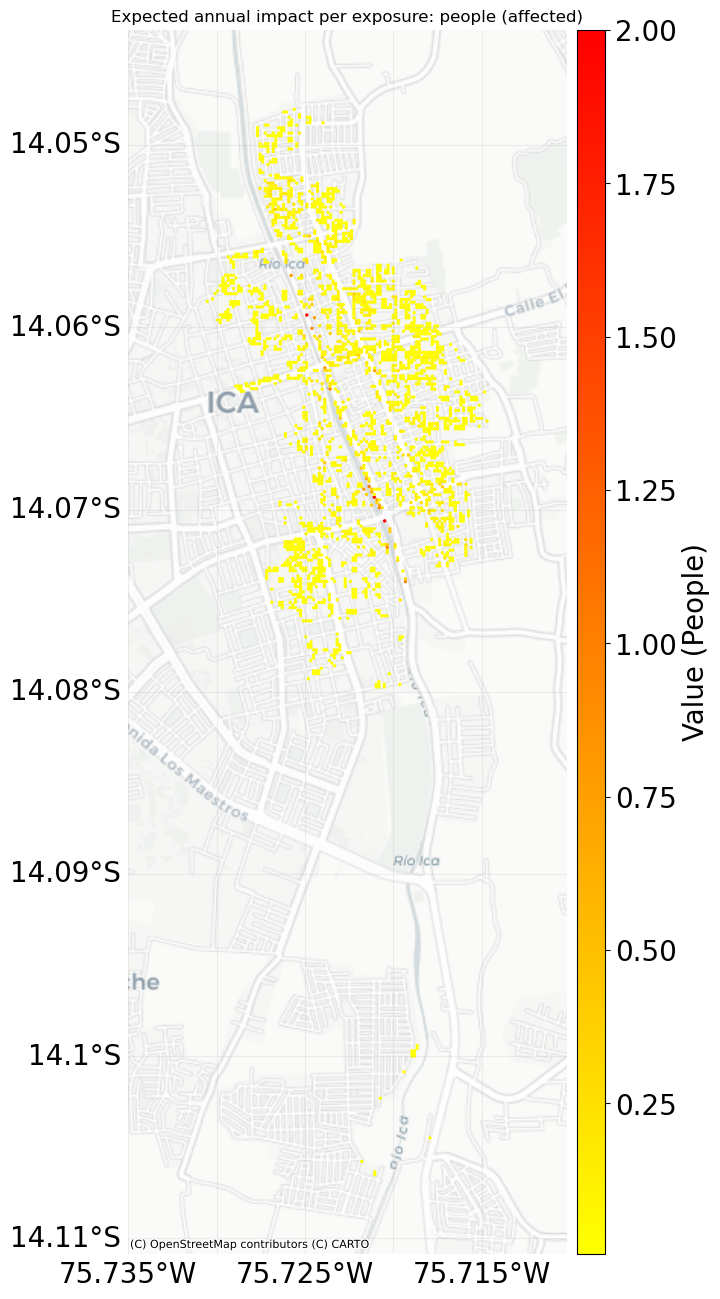

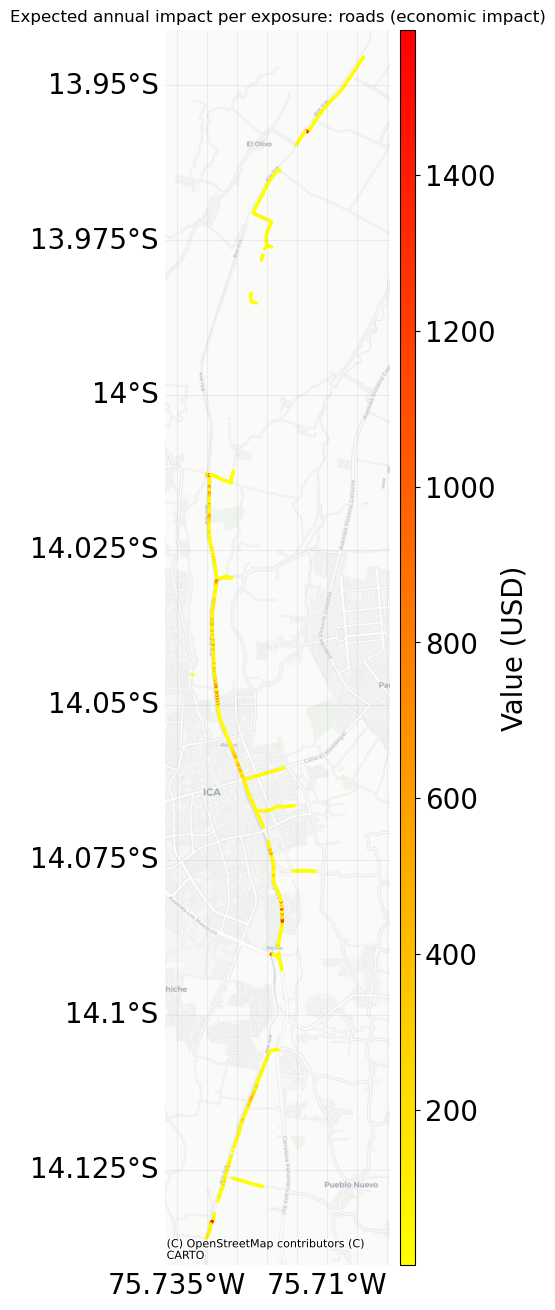

In [17]:
import contextily as ctx

# We can map the average annual impact by individual exposure point:
for imp, asset_name in zip([imp_residences_economic, imp_people_affected, imp_roads_economic], entity_names):
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=True,                   # Don't plot locations with zero impacts
        pop_name=False,                     # Don't plot place names
        buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
        s=2,                                # The size of point markers on the plot
        zoom=14,                            # Level of detail to add to the basemap
        cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        url=ctx.providers.CartoDB.Positron  # Basemap provider
    )
    axis.set_title(f"Expected annual impact per exposure: {asset_name}")

# Note: there are also methods to plot hexbin and raster plots (as with Exposures)

2026-07-07 17:19:11,320 - climada.engine.impact - INFO - Computing exceedance impact map for return periods: [40, 225]


/Users/chrisfairless/repos/climada/climada_python/climada/util/interpolation.py:236: RuntimeWarning: divide by zero encountered in log10
  fill_value = (y_train[0], np.log10(y_asymptotic) if logy else y_asymptotic)


Exposure level return period exceedance:


,geometry,40,225
0,POINT (-75.73100 -14.06785),0.0,0.0
1,POINT (-75.73100 -14.06770),0.0,0.0
2,POINT (-75.73100 -14.06756),0.0,0.0
3,POINT (-75.73100 -14.06741),0.0,0.0
4,POINT (-75.73100 -14.06727),0.0,0.0


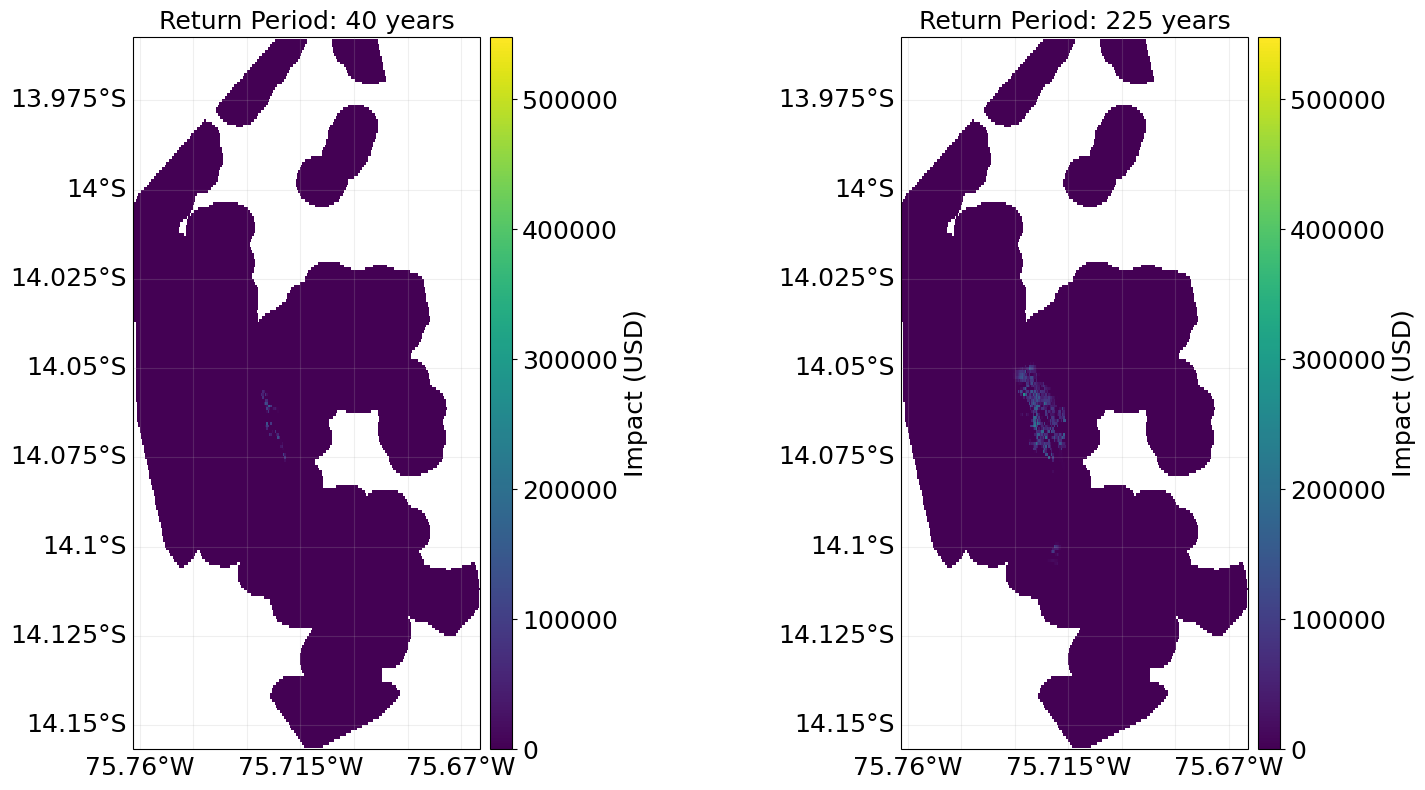

In [18]:
from IPython.display import display
from climada.util.plot import plot_from_gdf

# Looking at the impact data across all events gives us the information about the impact per exposed point instead.
# Here we look at the results for residences, but you can change this for people or roads
imp = imp_residences_economic

# TODO zoom in for these plots

# Generate a GeoDataFrame of custom return period impacts for every exposure:
custom_return_periods = [40, 225]
local_exceedance, label, col_label = imp.local_exceedance_impact(
    return_periods=custom_return_periods,
    method="extrapolate_constant",    # How to deal with interpolated and extrapolated impacts (default here is only interpolate)
    min_impact=0,            # Filter impacts below this value
    log_frequency=True,     
    log_impact=True,
)

print("Exposure level return period exceedance:")
display(local_exceedance.head())

# Plot impacts at custom return periods
# Note that CLIMADA interpolates values around observations, often giving hard-to-read plots
# In CLIMADA 6.1 and higher, set mask_distance to reduce this interpolation.
axis = plot_from_gdf(
    local_exceedance,
    colorbar_name=label,
    title_subplots=col_label,
    figsize=(18, 8)
)
plt.tight_layout()

## Assets affected

What if we want to count the number of assets affected or the number damaged according to a particular thresholds? CLIMADA offers a couple of ways to do this.

This section only looks at the Residential exposure, but you can change which entity file is analyzed in the code here. 

In [19]:
entity = entity_residences

In [20]:
# To get a broad sense of the value of exposures that are affected by any hazard (across all events), the Exposures' 
# `affected_total_value` attribute is helpful:
affected_value = entity.exposures.affected_total_value(
    hazard=haz,
    threshold_affected=0,
    overwrite_assigned_centroids=False
)
affected_households = affected_value / RESIDENCE_VALUE_USD
print(f"Total value of affected exposures: {affected_value:,.0f} USD")
print(f"Total number of affected households: {affected_households:,.0f}")

2026-07-07 17:19:48,651 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
Total value of affected exposures: 954,595,291 USD
Total number of affected households: 9,801


2026-07-07 17:19:48,741 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
Average annual number of affected households: 67
Average annual value of affected housing: 6,499,644 USD


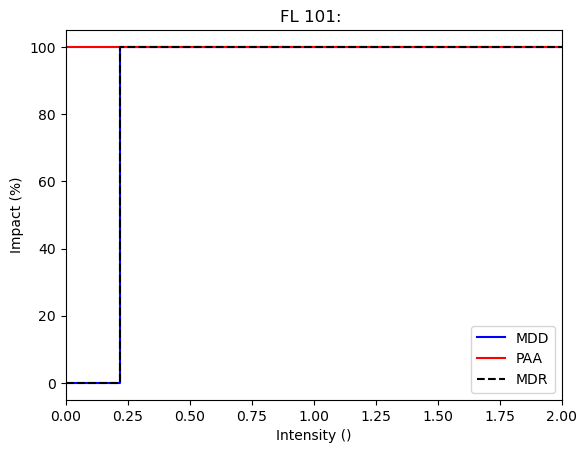

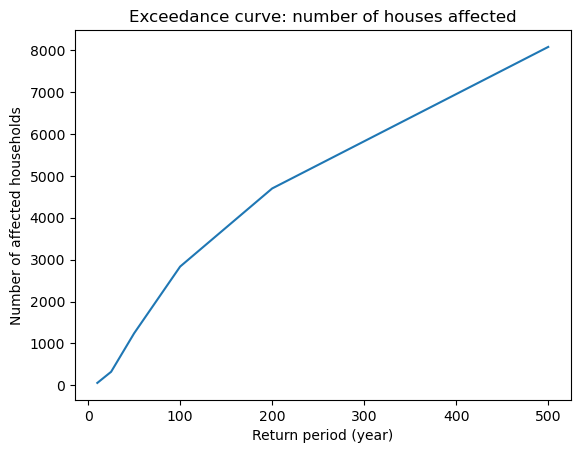

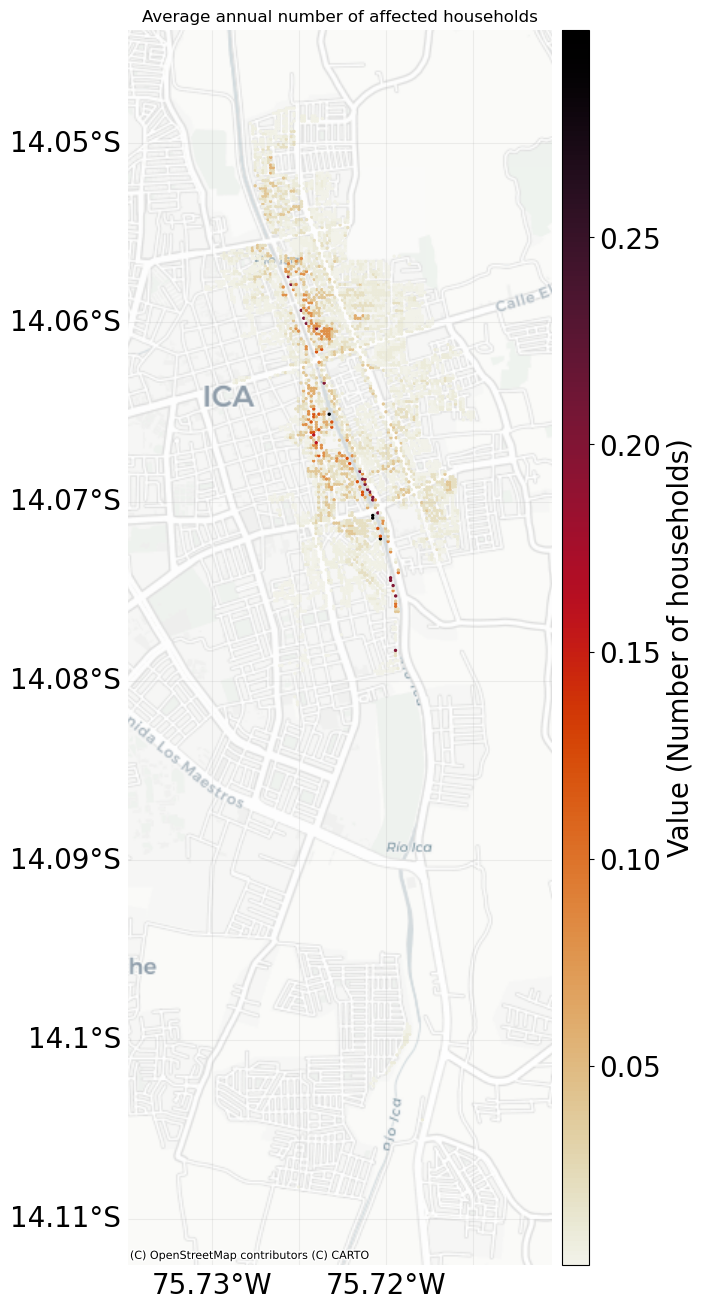

In [21]:
from climada.entity import ImpactFunc, ImpactFuncSet
# But to make this probabilistic – that is, to get the number of affected houses at different return periods, 
# or to get an average annual value – we need to run another impact calculation, this time with a step function as the 
# impact function.

# We can use inbuilt functionality to create a stepped impact function
# (Note that this is a bit redundant when we already have an step function in our impact function set,)
# (but you won't always have this, and creating custom step functions is very useful)
# First choose a flood depth that counts as affected:
affected_threshold = 0.22    # This is about the water depth where we model 20% impact with this uncalibrated impact function

# Create an impact function
affected_step_impf = ImpactFunc.from_step_impf(
    intensity=(0, affected_threshold, 2),
    haz_type="FL",
    mdd=(0, 1),
    paa=(1, 1),
    impf_id=101
)

# Plot the impact function
affected_step_impf.plot()

# Add it to a new ImpactFuncSet for use in a risk calculation
affected_impfset = ImpactFuncSet([affected_step_impf])

# We could do this next calculation with the affected value of houses, but let's divide our exposure by the value of an average house to get the number of affected households instead.
entity_households = copy.deepcopy(entity)
new_gdf = entity_households.exposures.gdf
new_gdf["value"] = new_gdf["value"] / RESIDENCE_VALUE_USD
entity_households.exposures.set_gdf(new_gdf)
entity_households.exposures.value_unit = "Number of households"

# And create a new ImpactCalc and Impact object
imp_calc_affected = ImpactCalc(
    exposures=entity_households.exposures,
    impfset=affected_impfset,
    hazard=haz
)
imp_affected = imp_calc_affected.impact(
    save_mat=True,          # Save the impact matrix (see below). This can be large, but we want it to explore some additional calculations 
    assign_centroids=False  # Don't (re)assign centroids 
)

# Now we can get probabilistic information on the average annual affected households and the household affected by return period
aal_affected_households = imp_affected.aai_agg
aal_affected_value = aal_affected_households * RESIDENCE_VALUE_USD
print(f"Average annual number of affected households: {aal_affected_households:,.0f}")
print(f"Average annual value of affected housing: {aal_affected_value:,.0f} USD")

# And we can extract an affected exceedance curve in the same way
affected_freq_curve = imp_affected.calc_freq_curve(return_per=HAZARD_RETURN_PERIODS)
axis = affected_freq_curve.plot()
_ = axis.set_title("Exceedance curve: number of houses affected")
_ = axis.set_ylabel("Number of affected households")

# And plot the expected value of affected households at custom return periods
axis_plot = imp_affected.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=2,                                # The size of point markers on the plot
    zoom=14,                            # Level of detail to add to the basemap
    url=ctx.providers.CartoDB.Positron  # Basemap provider
)
_ = axis_plot.set_title("Average annual number of affected households")
